# Blockschaltbild-Rechner (schnell + schrittweise)

Dieses Notebook reduziert ein Blockschaltbild automatisch zu einer Gesamt-Übertragungsfunktion.

Kurzprinzip:
- Signalpfade als gerichtete Kanten mit Gain $G(s)$
- Schleife $L$ wird mit Faktor $1/(1-L)$ aufgeloest
- Zwischenknoten werden eliminiert (Serie/Parallel entsteht automatisch)

Ziel: schnelle Eingabe wie im Skript, danach klare Schritt-fuer-Schritt-Reduktion.

In [39]:
import re
import sys
from pathlib import Path
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, deque
from IPython.display import display, Markdown

projekt_root = Path.cwd()
if not (projekt_root / 'regelungstechnik').exists():
    projekt_root = projekt_root.parent
if str(projekt_root) not in sys.path:
    sys.path.insert(0, str(projekt_root))

s = sp.symbols('s')
sp.init_printing()

## 1. Eigene kleine Graph-Klasse

Statt `networkx` verwenden wir eine einfache Adjazenzstruktur: `adj[u][v]` speichert
die Verstärkung der Kante $u \to v$, `labels[(u,v)]` optional einen Blocknamen
(z.B. `'G1'`) nur zur besseren Lesbarkeit im Ausgangsdiagramm.

In [40]:
class Graph:
    def __init__(self):
        self.adj = {}
        self.labels = {}   # (u, v) -> optionaler Blockname
        self.sum_nodes = set()

    def add_node(self, n):
        if n not in self.adj:
            self.adj[n] = {}

    def nodes(self):
        return list(self.adj.keys())

    def has_edge(self, u, v):
        return u in self.adj and v in self.adj[u]

    def add_edge(self, u, v, gain):
        self.add_node(u)
        self.add_node(v)
        self.adj[u][v] = gain

    def get_gain(self, u, v):
        return self.adj[u][v]

    def set_gain(self, u, v, gain):
        self.adj[u][v] = gain

    def remove_edge(self, u, v):
        del self.adj[u][v]
        self.labels.pop((u, v), None)

    def remove_node(self, v):
        self.adj.pop(v, None)
        self.sum_nodes.discard(v)
        for u in self.adj:
            self.adj[u].pop(v, None)
        for key in [k for k in self.labels if v in k]:
            self.labels.pop(key, None)

    def predecessors(self, v):
        return [u for u in self.adj if v in self.adj[u]]

    def successors(self, v):
        return list(self.adj.get(v, {}).keys())

    def in_degree(self, v):
        return sum(1 for u in self.adj if v in self.adj[u])

    def out_degree(self, v):
        return len(self.adj.get(v, {}))

    def edges(self):
        for u in self.adj:
            for v, g in self.adj[u].items():
                yield u, v, g


def new_diagram():
    return Graph()


def mark_sum_node(G, *nodes):
    for n in nodes:
        G.add_node(n)
        G.sum_nodes.add(str(n))


def add_block(G, u, v, tf, sign=1, label=None):
    gain = sp.nsimplify(sp.sympify(tf)) * sign
    u = str(u).strip()
    v = str(v).strip()
    if G.has_edge(u, v):
        G.set_gain(u, v, sp.simplify(G.get_gain(u, v) + gain))
        if label is not None:
            bisher = G.labels.get((u, v))
            G.labels[(u, v)] = f"{bisher}+{label}" if bisher else label
    else:
        G.add_edge(u, v, sp.simplify(gain))
        if label is not None:
            G.labels[(u, v)] = label


def _parse_edge_line(line):
    # Format: u -> v : tf [Label] -
    # '-' am Ende bedeutet negatives Summierzeichen.
    body = line.strip()
    neg = body.endswith(" -") or body.endswith("-")
    if neg:
        body = body[:-1].strip()

    m = re.match(r"^\s*([^\-:]+?)\s*->\s*([^:]+?)\s*:\s*(.+?)\s*$", body)
    if not m:
        raise ValueError(f"Ungueltiges Format: '{line}'")

    u = m.group(1).strip()
    v = m.group(2).strip()
    rhs = m.group(3).strip()

    label = None
    lm = re.search(r"\[(.+?)\]\s*$", rhs)
    if lm:
        label = lm.group(1).strip()
        rhs = rhs[:lm.start()].strip()

    tf = sp.sympify(rhs, locals={"s": s})
    sign = -1 if neg else 1
    return u, v, tf, sign, label


def build_diagram_from_text(spec):
    '''
    Baut ein Diagramm aus einem Textblock.

    Zeilenformate:
    - u -> v : tf
    - u -> v : tf [Label]
    - u -> v : tf [Label] -    (negativer Summierzweig)
    - @sum e                   (markiert Summierknoten e)
    '''
    G = new_diagram()
    for raw in spec.splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("@sum "):
            name = line[5:].strip()
            if name:
                mark_sum_node(G, name)
            continue
        u, v, tf, sign, label = _parse_edge_line(line)
        add_block(G, u, v, tf, sign=sign, label=label)
    return G

## 2. Schnelle Eingabe in einer Zeile pro Pfeil

Jeder Pfeil wird mit `add_block(...)` angelegt:

```python
add_block(G, u, v, tf, sign=1, label='G1')
```

Noch schneller: unten in Abschnitt 5 kannst du das gesamte Diagramm als Textblock eingeben.

Minimalregeln:
- `u` = Startknoten, `v` = Zielknoten
- `tf` = Uebertragungsfunktion in `s` (oder Zahl)
- `sign=-1` fuer negative Rueckfuehrung an Summierstellen
- gleiche Kante mehrfach => automatische Addition (Parallelschaltung)

## 3. Diagramm zeichnen (nur mit matplotlib)

In [41]:
def _preset_positions_for_lecture(G):
    # Festes Layout wie im Vorlesungsbild (orthogonale Fuehrung).
    known = {
        'W': (-4.0, -2.0),
        'E1': (-2.4, -2.0),
        'E2': (0.0, -1.0),
        'Z': (0.0, 0.6),     # vertikaler Stoereingang auf E2
        'X3': (3.1, -1.0),
        'E3': (4.7, -2.0),
        'Y': (8.0, -1.0),
        'E4': (8.0, -2.0),
    }
    node_set = set(G.nodes())

    # Sobald ein klarer Teil des Vorlesungsmodells erkannt wird,
    # bleiben die Koordinaten auch bei reduzierten Teilschritten stabil.
    anchor = {'W', 'E2', 'Y'}
    if not anchor.issubset(node_set):
        return None

    pos = {}
    for n in G.nodes():
        if n in known:
            pos[n] = known[n]
    return pos


def layout_graph(G):
    # Zuerst versuchen wir ein skriptnahes Festlayout.
    preset = _preset_positions_for_lecture(G)
    if preset is not None:
        # Unbekannte Restknoten (falls vorhanden) rechts anordnen.
        if len(preset) == len(G.nodes()):
            return preset
        remaining = [n for n in G.nodes() if n not in preset]
        x0 = max(p[0] for p in preset.values()) + 2.5
        for i, n in enumerate(sorted(remaining, key=str)):
            preset[n] = (x0 + 1.8 * (i // 3), -0.5 * (i % 3))
        return preset

    # Fallback: Schichten-Layout, Quellen links, Senken rechts.
    nodes = G.nodes()
    sources = [n for n in nodes if G.in_degree(n) == 0]
    if not sources:
        sources = nodes[:1]

    level = {}
    queue = deque()
    for src in sources:
        level[src] = 0
        queue.append(src)

    while queue:
        u = queue.popleft()
        for v in G.successors(u):
            if v == u:
                continue
            if v not in level:
                level[v] = level[u] + 1
                queue.append(v)

    for n in nodes:
        if n not in level:
            level[n] = (max(level.values()) + 1) if level else 0

    groups = defaultdict(list)
    for n in nodes:
        groups[level[n]].append(n)

    pos = {}
    for lvl, ns in groups.items():
        ns.sort(key=str)
        k = len(ns)
        for i, n in enumerate(ns):
            y = (i - (k - 1) / 2.0)
            pos[n] = (lvl * 3.2, y * 2.2)
    return pos


def _is_one_gain(gain):
    return sp.simplify(gain - 1) == 0


def _block_label_text(label):
    if label is None:
        return None
    txt = str(label).strip()
    if not txt:
        return None
    if re.match(r'^[A-Za-z][A-Za-z0-9_]*$', txt):
        return f"{txt}(s)"
    return txt


def _to_math_text(expr_text):
    try:
        expr = sp.sympify(expr_text, locals={'s': s})
        return '$' + sp.latex(expr) + '$'
    except Exception:
        return expr_text


def _manhattan_path(x1, y1, x2, y2, backward=False):
    eps = 1e-9
    if abs(x1 - x2) < eps or abs(y1 - y2) < eps:
        return [(x1, y1), (x2, y2)]
    if backward:
        xk = max(x1, x2) + 1.2
    else:
        xk = (x1 + x2) / 2.0
    return [(x1, y1), (xk, y1), (xk, y2), (x2, y2)]


def _polyline_midpoint(points):
    segs = []
    total = 0.0
    for i in range(len(points) - 1):
        x1, y1 = points[i]
        x2, y2 = points[i + 1]
        L = ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5
        segs.append((x1, y1, x2, y2, L))
        total += L
    if total == 0.0:
        return points[0]
    half = 0.5 * total
    acc = 0.0
    for x1, y1, x2, y2, L in segs:
        if acc + L >= half and L > 0:
            t = (half - acc) / L
            return (x1 + t * (x2 - x1), y1 + t * (y2 - y1))
        acc += L
    return points[-1]


def draw_diagram(G, title='', show_unlabeled_formulas=False):
    pos = layout_graph(G)
    all_x = [p[0] for p in pos.values()] or [0]
    all_y = [p[1] for p in pos.values()] or [0]
    width = max(all_x) - min(all_x)
    height = max(all_y) - min(all_y)
    fig, ax = plt.subplots(figsize=(max(8.0, width + 3.0), max(4.5, height + 2.8)))

    # Kanten und Blockdarstellung: nur orthogonale Linien mit Abknickung.
    for u, v, gain in G.edges():
        if u == v:
            continue
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        backward = x2 <= x1
        path = _manhattan_path(x1, y1, x2, y2, backward=backward)

        for i in range(len(path) - 1):
            xa, ya = path[i]
            xb, yb = path[i + 1]
            ax.plot([xa, xb], [ya, yb], color='black', linewidth=1.4, zorder=1)

        # Pfeilspitze nur am Ende.
        xa, ya = path[-2]
        xb, yb = path[-1]
        ax.annotate('', xy=(xb, yb), xytext=(xa, ya),
                    arrowprops=dict(arrowstyle='-|>', lw=1.4, color='black'), zorder=2)

        block_label = _block_label_text(G.labels.get((u, v)))
        is_identity = _is_one_gain(gain)
        mx, my = _polyline_midpoint(path)

        # Skriptstil: nur benannte Glieder als Blockkaesten.
        if block_label is not None:
            ax.text(
                mx, my, _to_math_text(block_label),
                fontsize=10, ha='center', va='center',
                bbox=dict(boxstyle='square,pad=0.20', fc='white', ec='black', lw=1.2),
                zorder=4
            )
        elif show_unlabeled_formulas and not is_identity:
            ax.text(
                mx, my, '$' + sp.latex(gain) + '$',
                fontsize=8.5, ha='center', va='center',
                bbox=dict(boxstyle='square,pad=0.12', fc='white', ec='black', lw=0.8),
                zorder=4
            )

        # Summier-Vorzeichen am Zielknoten anzeigen.
        if v in G.sum_nodes and u != v:
            sign = '-' if sp.simplify(gain).could_extract_minus_sign() else '+'
            sx = x2 - 0.30
            sy = y2 + (0.18 if sign == '+' else -0.18)
            ax.text(sx, sy, sign, fontsize=12, fontweight='bold', ha='center', va='center', zorder=5)

    # Knoten: Additionskreise ohne Sigma-Text.
    for n in G.nodes():
        x, y = pos[n]
        if n in G.sum_nodes:
            circ = mpatches.Circle((x, y), 0.24, facecolor='white', edgecolor='black', linewidth=1.5, zorder=3)
            ax.add_patch(circ)
            ax.text(x, y - 0.42, str(n), ha='center', va='top', fontsize=8.5, zorder=4)
        else:
            dot = mpatches.Circle((x, y), 0.04, facecolor='black', edgecolor='black', zorder=3)
            ax.add_patch(dot)
            ax.text(x, y + 0.22, str(n), ha='center', va='bottom', fontsize=9.5, zorder=4)

    # Selbstschleifen orthogonal (rechteckiger Loop).
    for u, v, gain in G.edges():
        if u != v:
            continue
        x, y = pos[u]
        loop = [(x, y), (x, y + 0.75), (x + 0.75, y + 0.75), (x + 0.75, y)]
        for i in range(len(loop) - 1):
            xa, ya = loop[i]
            xb, yb = loop[i + 1]
            ax.plot([xa, xb], [ya, yb], color='black', linewidth=1.4, zorder=2)
        ax.annotate('', xy=(x, y), xytext=(x + 0.75, y),
                    arrowprops=dict(arrowstyle='-|>', lw=1.4, color='black'), zorder=2)
        ax.text(
            x + 1.0, y + 0.75, '$L=' + sp.latex(gain) + '$',
            fontsize=8.5, ha='left', va='center',
            bbox=dict(boxstyle='square,pad=0.15', fc='white', ec='black', lw=0.8),
            zorder=4
        )

    ax.set_xlim(min(all_x) - 1.5, max(all_x) + 1.7)
    ax.set_ylim(min(all_y) - 1.5, max(all_y) + 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 4. Reduktionsregeln + Hilfsfunktion `reduce_and_show`

`PROTECTED` enthaelt Knoten, die **nicht** eliminiert werden duerfen – standardmaessig
alle Quellen (kein Eingang) und Senken (kein Ausgang). Willst du die Uebertragungsfunktion
zu einem *inneren* Signal wissen, uebergib seinen Namen einfach in `extra_protected`.

Jeder Schritt gibt jetzt eine **detaillierte** Erklärung aus: welche Kante(n) genau
verrechnet werden, mit welcher Formel, und was dabei neu entsteht.

In [42]:
def get_protected(G, extra_protected=None):
    protected = {n for n in G.nodes() if G.in_degree(n) == 0 or G.out_degree(n) == 0}
    if extra_protected:
        protected |= set(extra_protected)
    return protected


def resolve_self_loop(G, v):
    # Loest eine Selbstschleife an Knoten v auf (falls vorhanden). Gibt eine
    # ausfuehrliche Beschreibung zurueck oder None, falls keine Schleife vorliegt.
    if not G.has_edge(v, v):
        return None
    L = G.get_gain(v, v)
    factor = sp.simplify(1 / (1 - L))

    zeilen = [
        f"**Rückführschleife bei Knoten `{v}` wird aufgelöst.**",
        f"Es gibt eine Schleife ${v} \\to {v}$ mit Schleifenverstärkung $L={sp.latex(L)}$.",
        f"Regel: alle *eingehenden* Kanten von `{v}` (außer der Schleife selbst) werden mit "
        f"$\\dfrac{{1}}{{1-L}} = \\dfrac{{1}}{{1-({sp.latex(L)})}} = {sp.latex(factor)}$ multipliziert, "
        f"danach wird die Schleife entfernt:",
    ]
    G.remove_edge(v, v)
    for u in list(G.predecessors(v)):
        if u == v:
            continue
        old = G.get_gain(u, v)
        new = sp.simplify(old * factor)
        zeilen.append(f"- Kante ${u} \\to {v}$: ${sp.latex(old)} \\cdot {sp.latex(factor)} = {sp.latex(new)}$")
        G.set_gain(u, v, new)
    return "\n\n".join(zeilen)


def eliminate_node(G, v):
    # Eliminiert Knoten v (darf keine Selbstschleife mehr haben). Gibt eine
    # ausfuehrliche, kantenweise Beschreibung der Umformung zurueck.
    preds = [(u, G.get_gain(u, v)) for u in G.predecessors(v)]
    succs = [(w, G.get_gain(v, w)) for w in G.successors(v)]
    in_deg, out_deg = len(preds), len(succs)

    if in_deg == 1 and out_deg == 1:
        regel = "Serienschaltung"
    elif in_deg == 1 or out_deg == 1:
        regel = "Serien-/Verzweigungs-Zusammenfassung"
    else:
        regel = "allgemeine Knoteneliminierung (mehrere Pfade &rarr; Parallelschaltung)"

    zeilen = [
        f"**Knoten `{v}` wird eliminiert** ({regel}).",
        f"`{v}` hat {in_deg} eingehende und {out_deg} ausgehende Kante(n). Jede Kombination aus "
        f"einer eingehenden Kante $u\\to {v}$ (Verstärkung $a$) und einer ausgehenden Kante "
        f"${v}\\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \\to w$ mit "
        f"Verstärkung $a \\cdot b$:",
    ]

    for u, a in preds:
        for w, b in succs:
            gain = sp.simplify(a * b)
            if u == w:
                zeilen.append(
                    f"- ${u} \\to {v} \\to {w}$: da Start- und Zielknoten hier gleich sind, entsteht "
                    f"eine **neue Rückführschleife** bei `{u}` mit "
                    f"$({sp.latex(a)}) \\cdot ({sp.latex(b)}) = {sp.latex(gain)}$")
                if G.has_edge(u, u):
                    alt = G.get_gain(u, u)
                    gain = sp.simplify(alt + gain)
                    zeilen.append(f"  (addiert zu bereits vorhandener Schleife bei `{u}`, alt: ${sp.latex(alt)}$)")
                G.add_edge(u, u, gain)
            else:
                if G.has_edge(u, w):
                    alt = G.get_gain(u, w)
                    neu = sp.simplify(alt + gain)
                    zeilen.append(
                        f"- ${u} \\to {v} \\to {w}$ ergibt $({sp.latex(a)}) \\cdot ({sp.latex(b)}) = {sp.latex(gain)}$, "
                        f"addiert zur bereits vorhandenen Kante ${u} \\to {w}$ (alt: ${sp.latex(alt)}$) "
                        f"&rarr; neu: ${sp.latex(neu)}$ (**Parallelschaltung**)")
                    G.set_gain(u, w, neu)
                else:
                    zeilen.append(
                        f"- ${u} \\to {v} \\to {w}$: neue Kante ${u} \\to {w}$ mit "
                        f"$({sp.latex(a)}) \\cdot ({sp.latex(b)}) = {sp.latex(gain)}$")
                    G.add_edge(u, w, gain)

    G.remove_node(v)
    return "\n\n".join(zeilen)


def choose_node_to_eliminate(G, protected):
    candidates = [n for n in G.nodes() if n not in protected and not G.has_edge(n, n)]
    if not candidates:
        return None
    candidates.sort(key=lambda n: (G.in_degree(n) * G.out_degree(n), str(n)))
    return candidates[0]


def simplify_step(G, protected):
    # Fuehrt GENAU EINEN Reduktionsschritt aus. Gibt eine ausfuehrliche
    # Beschreibung zurueck oder None, wenn nichts mehr zu tun ist.
    for n in list(G.nodes()):
        if G.has_edge(n, n):
            return resolve_self_loop(G, n)
    v = choose_node_to_eliminate(G, protected)
    if v is None:
        return None
    return eliminate_node(G, v)


def reduce_and_show(G, extra_protected=None, show_steps=True):
    # Reduziert G vollstaendig, zeigt jeden Schritt (optional) und das Endergebnis.
    protected = get_protected(G, extra_protected)
    if show_steps:
        draw_diagram(G, "Schritt 0: Ausgangsdiagramm")

    schritt = 0
    while True:
        beschreibung = simplify_step(G, protected)
        if beschreibung is None:
            break
        schritt += 1
        if show_steps:
            display(Markdown(f"### Schritt {schritt}"))
            display(Markdown(beschreibung))
            draw_diagram(G, f"Schritt {schritt}")

    display(Markdown("### Ergebnis"))
    for u, v, gain in G.edges():
        if u != v:
            tf_final = sp.simplify(gain)
            display(Markdown(f"$$ \\dfrac{{{sp.latex(sp.Symbol(str(v)))}(s)}}{{{sp.latex(sp.Symbol(str(u)))}(s)}} = "
                              f"{sp.latex(tf_final)} = {sp.latex(sp.cancel(tf_final))} $$"))
    return G

### 4a. Manuelle Steuerung: nach jedem Schritt selbst zeichnen

`reduce_and_show` fuehrt die komplette Reduktion in einem Rutsch aus. Willst du
stattdessen **selbst** bestimmen, wann der naechste Schritt kommt und jedes Mal
gezielt neu zeichnen (z.B. um dir das Diagramm laenger anzuschauen oder einen
Screenshot zu machen), nutze `next_step(G, protected)`:

- Jeder Aufruf fuehrt **genau einen** Reduktionsschritt aus, gibt die Erklaerung
  aus **und zeichnet das aktuelle Diagramm**.
- Du fuehrst die Zelle einfach **mehrmals aus** (z.B. mit Strg+Enter), bis
  "Fertig – keine weitere Reduktion moeglich." erscheint.

In [43]:
_step_counter = {"n": 0}

def start_diagram(G, extra_protected=None):
    # Setzt den Schrittzaehler zurueck, markiert PROTECTED-Knoten und zeichnet
    # das Ausgangsdiagramm. Danach next_step(G, protected) wiederholt aufrufen.
    _step_counter["n"] = 0
    protected = get_protected(G, extra_protected)
    draw_diagram(G, "Schritt 0: Ausgangsdiagramm")
    return protected


def next_step(G, protected):
    # Fuehrt GENAU EINEN Reduktionsschritt aus, zeigt die Erklaerung und
    # zeichnet das Diagramm danach. Einfach diese Zelle erneut ausfuehren,
    # um zum naechsten Schritt zu gehen.
    beschreibung = simplify_step(G, protected)
    if beschreibung is None:
        display(Markdown("**Fertig – keine weitere Reduktion moeglich.**"))
        display(Markdown("### Ergebnis"))
        for u, v, gain in G.edges():
            if u != v:
                tf_final = sp.simplify(gain)
                display(Markdown(
                    f"$$ \\dfrac{{{sp.latex(sp.Symbol(str(v)))}(s)}}{{{sp.latex(sp.Symbol(str(u)))}(s)}} = "
                    f"{sp.latex(tf_final)} = {sp.latex(sp.cancel(tf_final))} $$"))
        return
    _step_counter["n"] += 1
    display(Markdown(f"### Schritt {_step_counter['n']}"))
    display(Markdown(beschreibung))
    draw_diagram(G, f"Schritt {_step_counter['n']}")

## 5. Vorlesungsbeispiel (W, Z, G1...G6)

Diese Eingabe entspricht dem gezeigten Blockschaltbild aus dem Skript.

- Eingang: `W(s)`
- Stoergroesse: `Z(s)`
- Ausgang: `Y(s)`
- Zusatzbedingung: `K2*K3 = 2*K4`

Die Zelle darunter zeichnet zuerst das Blockschaltbild im Skriptstil und gibt danach die korrekten Uebertragungsfunktionen aus.

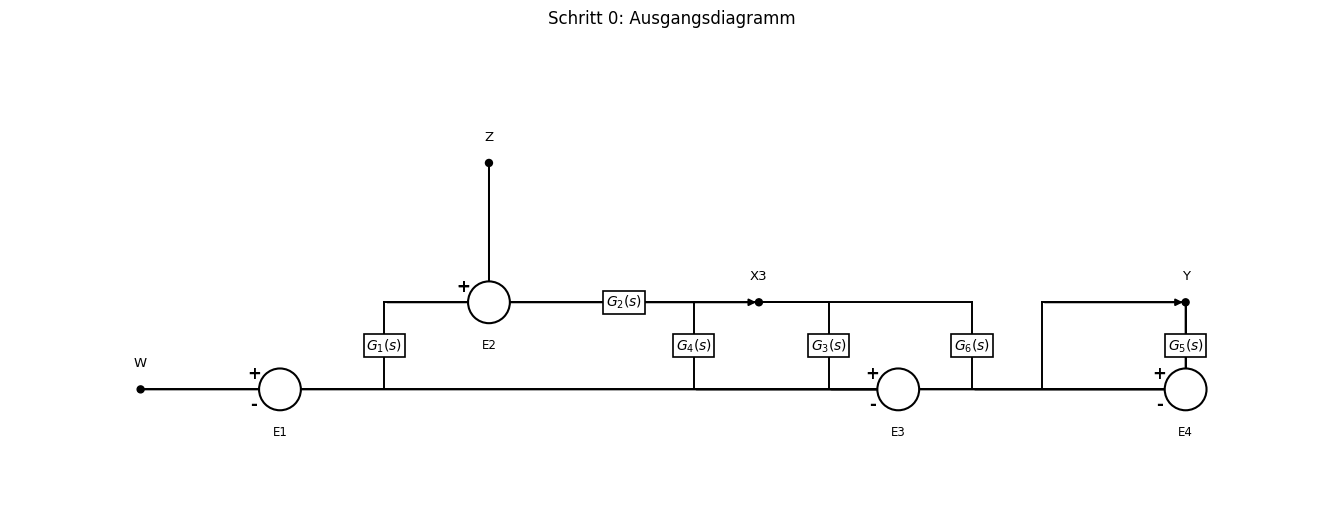

### Schritt 1

**Knoten `E1` wird eliminiert** (Serien-/Verzweigungs-Zusammenfassung).

`E1` hat 2 eingehende und 1 ausgehende Kante(n). Jede Kombination aus einer eingehenden Kante $u\to E1$ (Verstärkung $a$) und einer ausgehenden Kante $E1\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \to w$ mit Verstärkung $a \cdot b$:

- $E4 \to E1 \to E2$: neue Kante $E4 \to E2$ mit $(-1) \cdot (G_{1}) = - G_{1}$

- $W \to E1 \to E2$: neue Kante $W \to E2$ mit $(1) \cdot (G_{1}) = G_{1}$

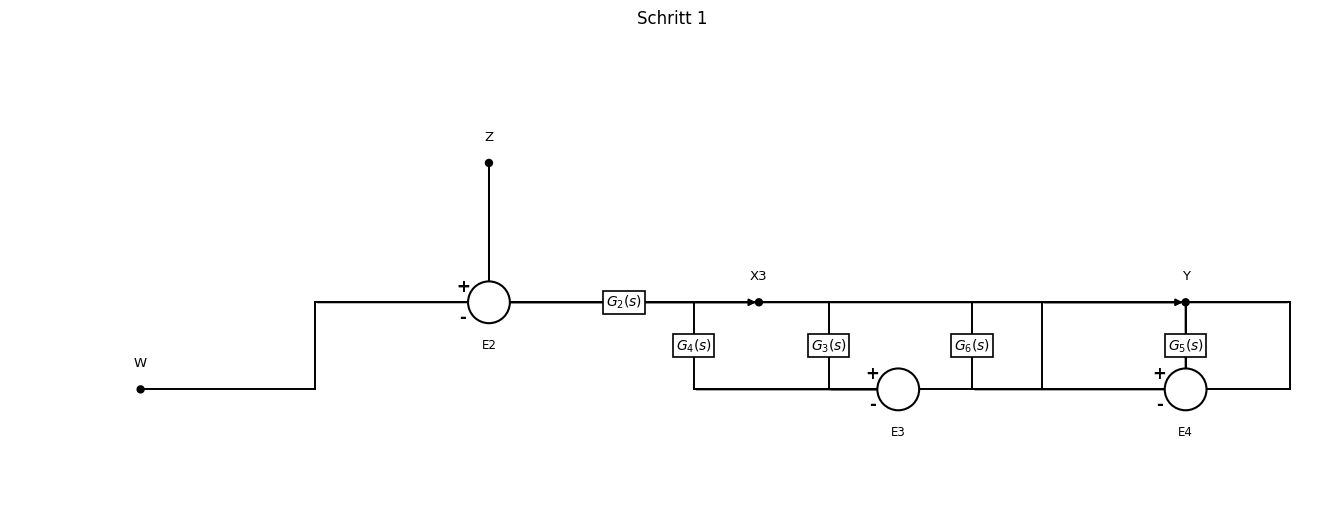

### Schritt 2

**Knoten `E3` wird eliminiert** (Serien-/Verzweigungs-Zusammenfassung).

`E3` hat 2 eingehende und 1 ausgehende Kante(n). Jede Kombination aus einer eingehenden Kante $u\to E3$ (Verstärkung $a$) und einer ausgehenden Kante $E3\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \to w$ mit Verstärkung $a \cdot b$:

- $E2 \to E3 \to Y$: neue Kante $E2 \to Y$ mit $(- G_{4}) \cdot (1) = - G_{4}$

- $X3 \to E3 \to Y$: neue Kante $X3 \to Y$ mit $(G_{3}) \cdot (1) = G_{3}$

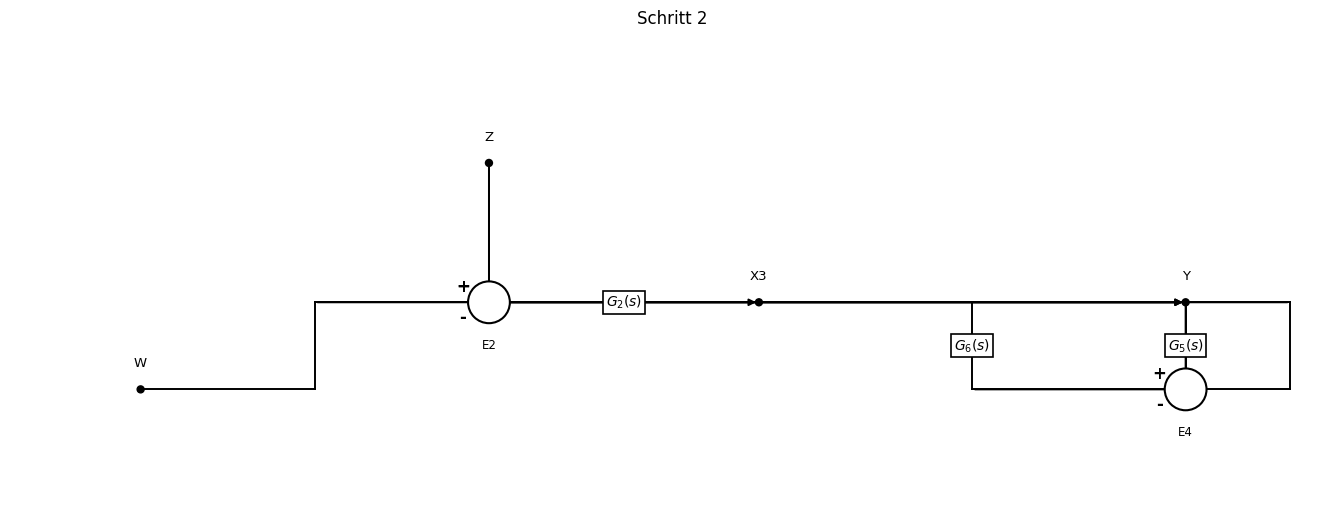

### Schritt 3

**Knoten `E4` wird eliminiert** (Serien-/Verzweigungs-Zusammenfassung).

`E4` hat 2 eingehende und 1 ausgehende Kante(n). Jede Kombination aus einer eingehenden Kante $u\to E4$ (Verstärkung $a$) und einer ausgehenden Kante $E4\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \to w$ mit Verstärkung $a \cdot b$:

- $X3 \to E4 \to E2$: neue Kante $X3 \to E2$ mit $(- G_{6}) \cdot (- G_{1}) = G_{1} G_{6}$

- $Y \to E4 \to E2$: neue Kante $Y \to E2$ mit $(G_{5}) \cdot (- G_{1}) = - G_{1} G_{5}$

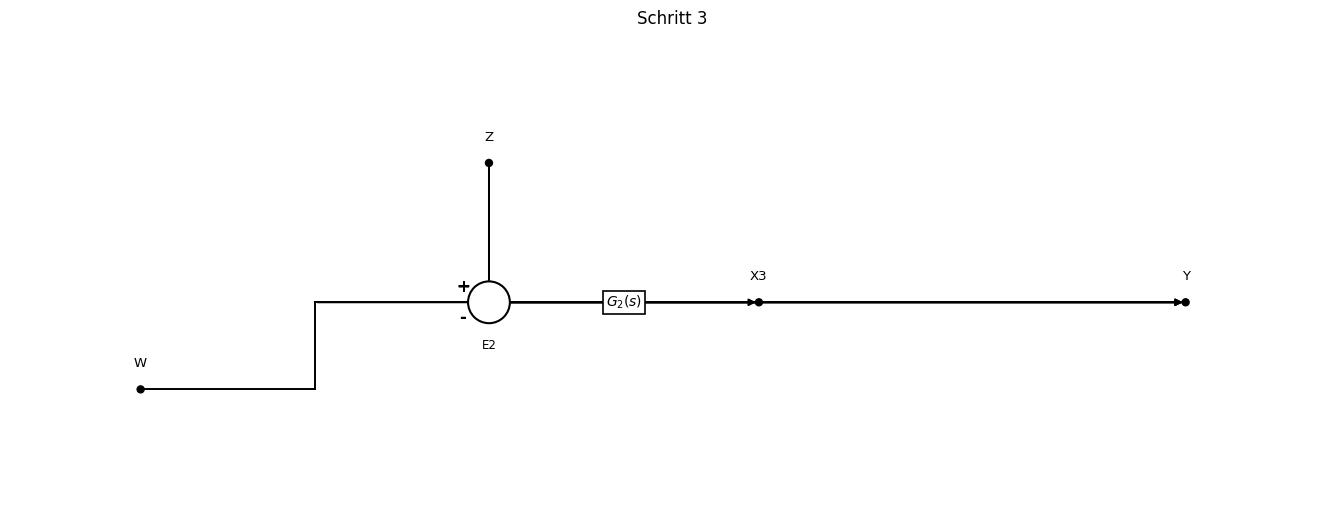

### Schritt 4

**Knoten `X3` wird eliminiert** (Serien-/Verzweigungs-Zusammenfassung).

`X3` hat 1 eingehende und 2 ausgehende Kante(n). Jede Kombination aus einer eingehenden Kante $u\to X3$ (Verstärkung $a$) und einer ausgehenden Kante $X3\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \to w$ mit Verstärkung $a \cdot b$:

- $E2 \to X3 \to Y$ ergibt $(G_{2}) \cdot (G_{3}) = G_{2} G_{3}$, addiert zur bereits vorhandenen Kante $E2 \to Y$ (alt: $- G_{4}$) &rarr; neu: $G_{2} G_{3} - G_{4}$ (**Parallelschaltung**)

- $E2 \to X3 \to E2$: da Start- und Zielknoten hier gleich sind, entsteht eine **neue Rückführschleife** bei `E2` mit $(G_{2}) \cdot (G_{1} G_{6}) = G_{1} G_{2} G_{6}$

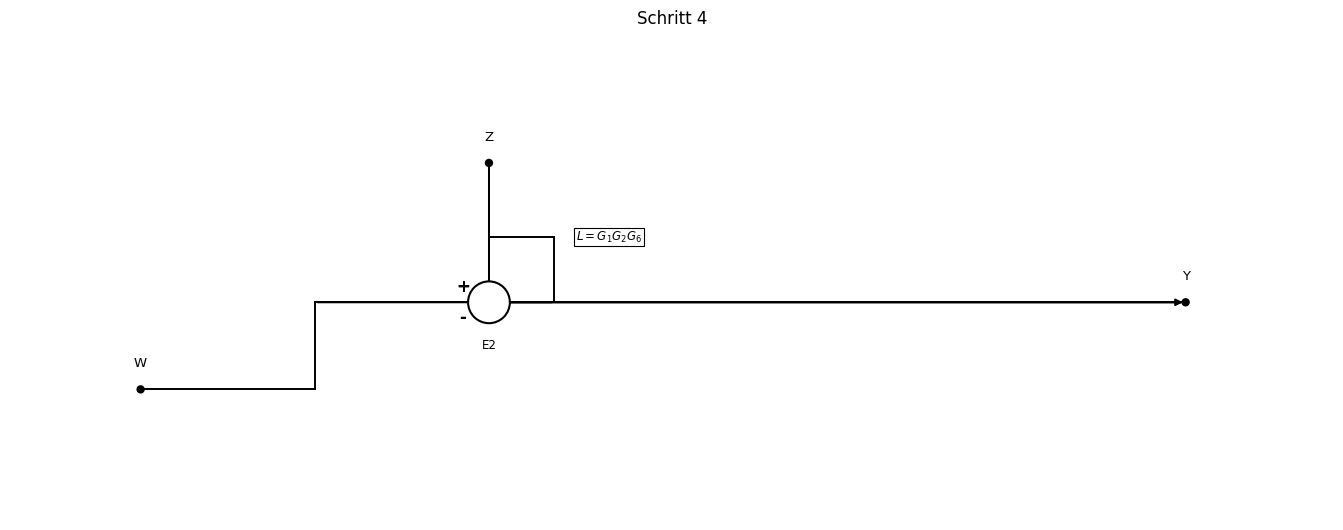

### Schritt 5

**Rückführschleife bei Knoten `E2` wird aufgelöst.**

Es gibt eine Schleife $E2 \to E2$ mit Schleifenverstärkung $L=G_{1} G_{2} G_{6}$.

Regel: alle *eingehenden* Kanten von `E2` (außer der Schleife selbst) werden mit $\dfrac{1}{1-L} = \dfrac{1}{1-(G_{1} G_{2} G_{6})} = - \frac{1}{G_{1} G_{2} G_{6} - 1}$ multipliziert, danach wird die Schleife entfernt:

- Kante $W \to E2$: $G_{1} \cdot - \frac{1}{G_{1} G_{2} G_{6} - 1} = - \frac{G_{1}}{G_{1} G_{2} G_{6} - 1}$

- Kante $Z \to E2$: $1 \cdot - \frac{1}{G_{1} G_{2} G_{6} - 1} = - \frac{1}{G_{1} G_{2} G_{6} - 1}$

- Kante $Y \to E2$: $- G_{1} G_{5} \cdot - \frac{1}{G_{1} G_{2} G_{6} - 1} = \frac{G_{1} G_{5}}{G_{1} G_{2} G_{6} - 1}$

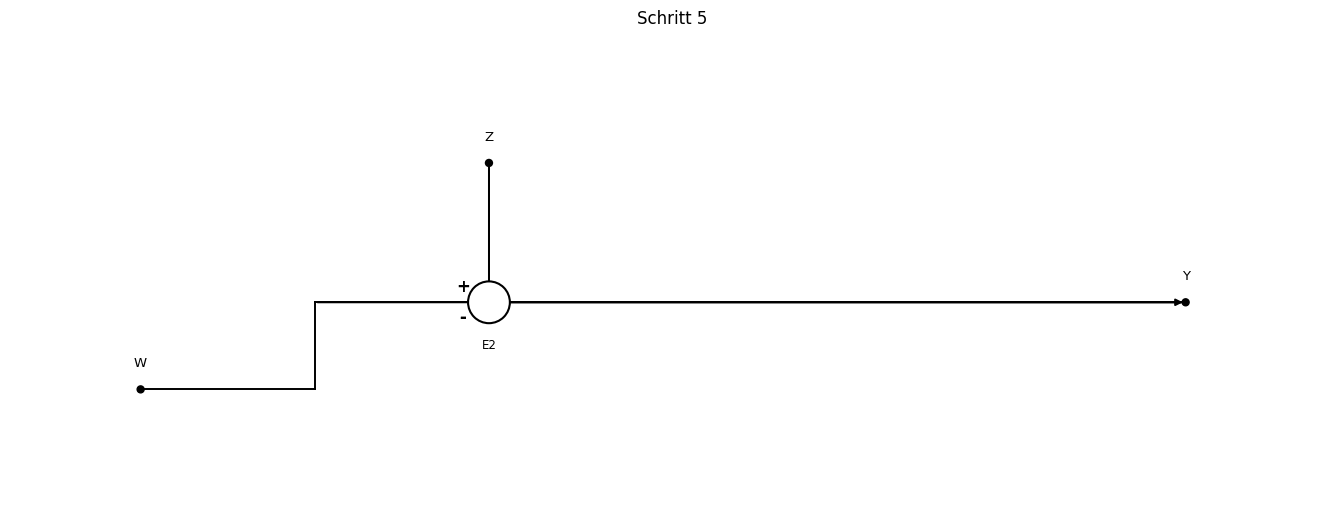

### Schritt 6

**Knoten `E2` wird eliminiert** (Serien-/Verzweigungs-Zusammenfassung).

`E2` hat 3 eingehende und 1 ausgehende Kante(n). Jede Kombination aus einer eingehenden Kante $u\to E2$ (Verstärkung $a$) und einer ausgehenden Kante $E2\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \to w$ mit Verstärkung $a \cdot b$:

- $W \to E2 \to Y$: neue Kante $W \to Y$ mit $(- \frac{G_{1}}{G_{1} G_{2} G_{6} - 1}) \cdot (G_{2} G_{3} - G_{4}) = \frac{G_{1} \left(- G_{2} G_{3} + G_{4}\right)}{G_{1} G_{2} G_{6} - 1}$

- $Z \to E2 \to Y$: neue Kante $Z \to Y$ mit $(- \frac{1}{G_{1} G_{2} G_{6} - 1}) \cdot (G_{2} G_{3} - G_{4}) = \frac{- G_{2} G_{3} + G_{4}}{G_{1} G_{2} G_{6} - 1}$

- $Y \to E2 \to Y$: da Start- und Zielknoten hier gleich sind, entsteht eine **neue Rückführschleife** bei `Y` mit $(\frac{G_{1} G_{5}}{G_{1} G_{2} G_{6} - 1}) \cdot (G_{2} G_{3} - G_{4}) = \frac{G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right)}{G_{1} G_{2} G_{6} - 1}$

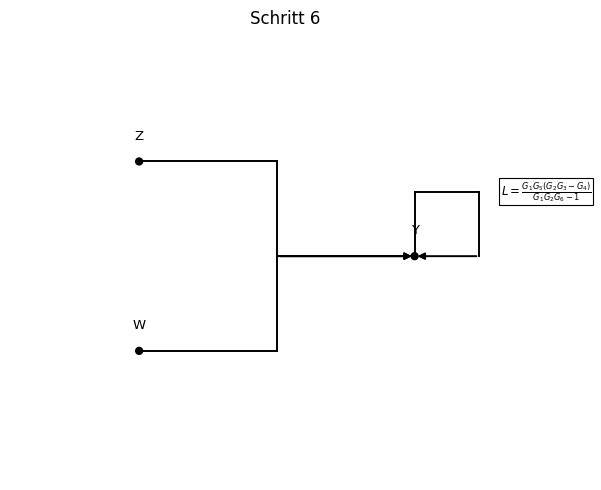

### Schritt 7

**Rückführschleife bei Knoten `Y` wird aufgelöst.**

Es gibt eine Schleife $Y \to Y$ mit Schleifenverstärkung $L=\frac{G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right)}{G_{1} G_{2} G_{6} - 1}$.

Regel: alle *eingehenden* Kanten von `Y` (außer der Schleife selbst) werden mit $\dfrac{1}{1-L} = \dfrac{1}{1-(\frac{G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right)}{G_{1} G_{2} G_{6} - 1})} = \frac{- G_{1} G_{2} G_{6} + 1}{- G_{1} G_{2} G_{6} + G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right) + 1}$ multipliziert, danach wird die Schleife entfernt:

- Kante $W \to Y$: $\frac{G_{1} \left(- G_{2} G_{3} + G_{4}\right)}{G_{1} G_{2} G_{6} - 1} \cdot \frac{- G_{1} G_{2} G_{6} + 1}{- G_{1} G_{2} G_{6} + G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right) + 1} = \frac{G_{1} \left(G_{2} G_{3} - G_{4}\right)}{- G_{1} G_{2} G_{6} + G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right) + 1}$

- Kante $Z \to Y$: $\frac{- G_{2} G_{3} + G_{4}}{G_{1} G_{2} G_{6} - 1} \cdot \frac{- G_{1} G_{2} G_{6} + 1}{- G_{1} G_{2} G_{6} + G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right) + 1} = \frac{G_{2} G_{3} - G_{4}}{- G_{1} G_{2} G_{6} + G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right) + 1}$

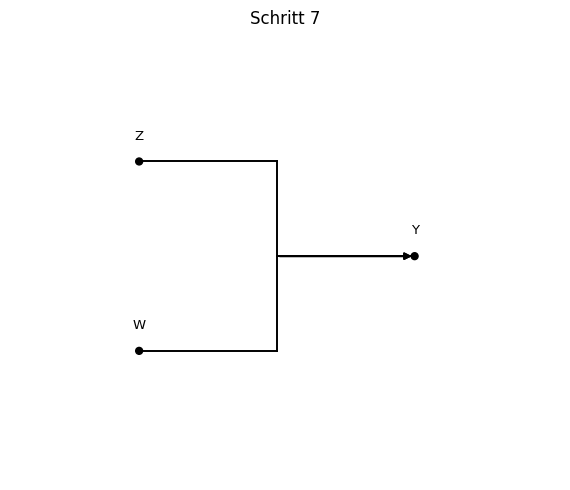

### Ergebnis

$$ \dfrac{Y(s)}{W(s)} = \frac{G_{1} \left(G_{2} G_{3} - G_{4}\right)}{- G_{1} G_{2} G_{6} + G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right) + 1} = \frac{G_{1} G_{2} G_{3} - G_{1} G_{4}}{G_{1} G_{2} G_{3} G_{5} - G_{1} G_{2} G_{6} - G_{1} G_{4} G_{5} + 1} $$

$$ \dfrac{Y(s)}{Z(s)} = \frac{G_{2} G_{3} - G_{4}}{- G_{1} G_{2} G_{6} + G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right) + 1} = \frac{G_{2} G_{3} - G_{4}}{G_{1} G_{2} G_{3} G_{5} - G_{1} G_{2} G_{6} - G_{1} G_{4} G_{5} + 1} $$

### Endformeln in Blocksymbolen

$$\frac{Y(s)}{W(s)}=\frac{G_{1} \left(G_{2} G_{3} - G_{4}\right)}{- G_{1} G_{2} G_{6} + G_{1} G_{5} \left(G_{2} G_{3} - G_{4}\right) + 1}$$

...

$$\frac{Y(s)}{Z(s)}=\frac{K_{2} K_{3} - K_{4}}{K_{1} K_{2} K_{3} K_{5} s - K_{1} K_{2} K_{6} s - K_{1} K_{4} K_{5} s + 1}$$

### Endformeln mit Zusatzbedingung $K_2K_3=2K_4$

$$\frac{Y(s)}{W(s)}=\frac{K_{1} K_{4} s}{- K_{1} K_{2} K_{6} s + K_{1} K_{4} K_{5} s + 1}$$

$$\frac{Y(s)}{Z(s)}=\frac{K_{4}}{- K_{1} K_{2} K_{6} s + K_{1} K_{4} K_{5} s + 1}$$

$$Y(s)=\left(\frac{K_{1} K_{4} s}{- K_{1} K_{2} K_{6} s + K_{1} K_{4} K_{5} s + 1}\right)W(s)+\left(\frac{K_{4}}{- K_{1} K_{2} K_{6} s + K_{1} K_{4} K_{5} s + 1}\right)Z(s)$$

In [44]:
# ---- Vorlesungsbeispiel aus dem Skript ----

# 1) Erst mit Blocksymbolen G1..G6 rechnen (K-Werte erst am Schluss einsetzen).
G1s, G2s, G3s, G4s, G5s, G6s = sp.symbols('G1 G2 G3 G4 G5 G6')
K1, K2, K3, K4, K5, K6 = sp.symbols('K1 K2 K3 K4 K5 K6')

diagram_text = r'''
@sum E1
@sum E2
@sum E3
@sum E4
W -> E1 : 1
E1 -> E2 : G1 [G_1]
Z -> E2 : 1
E2 -> X3 : G2 [G_2]
X3 -> E3 : G3 [G_3]
E2 -> E3 : G4 [G_4] -
E3 -> Y : 1
Y -> E4 : G5 [G_5]
X3 -> E4 : G6 [G_6] -
E4 -> E1 : 1 -
'''

G = build_diagram_from_text(diagram_text)
G_red = reduce_and_show(G, extra_protected=['Y'], show_steps=True)

tf_map = {(u, v): sp.simplify(gain) for u, v, gain in G_red.edges() if u != v}
T_WY_G = sp.simplify(tf_map.get(('W', 'Y'), 0))
T_ZY_G = sp.simplify(tf_map.get(('Z', 'Y'), 0))

display(Markdown('### Endformeln in Blocksymbolen'))
display(Markdown(f"$$\\frac{{Y(s)}}{{W(s)}}={sp.latex(T_WY_G)}$$"))
display(Markdown(f"$$\\frac{{Y(s)}}{{Z(s)}}={sp.latex(T_ZY_G)}$$"))

# 2) K-Werte/Glieder erst am Schluss einsetzen:
subs_blocks = {
    G1s: K1 * s,
    G2s: K2 / s,
    G3s: K3 * s,
    G4s: K4,
    G5s: K5,
    G6s: K6 * s,
}

T_WY = sp.simplify(sp.factor(T_WY_G.subs(subs_blocks)))
T_ZY = sp.simplify(sp.factor(T_ZY_G.subs(subs_blocks)))

display(Markdown('### Endformeln nach Einsetzen von $G_i(s)$'))
display(Markdown(f"$$\\frac{{Y(s)}}{{W(s)}}={sp.latex(T_WY)}$$"))
display(Markdown(f"$$\\frac{{Y(s)}}{{Z(s)}}={sp.latex(T_ZY)}$$"))

# 3) Zusatzbedingung aus dem Skript: K2*K3 = 2*K4
subs_rel = {K2 * K3: 2 * K4}
T_WY_rel = sp.simplify(sp.factor(T_WY.subs(subs_rel)))
T_ZY_rel = sp.simplify(sp.factor(T_ZY.subs(subs_rel)))

display(Markdown('### Endformeln mit Zusatzbedingung $K_2K_3=2K_4$'))
display(Markdown(f"$$\\frac{{Y(s)}}{{W(s)}}={sp.latex(T_WY_rel)}$$"))
display(Markdown(f"$$\\frac{{Y(s)}}{{Z(s)}}={sp.latex(T_ZY_rel)}$$"))
display(Markdown(
    f"$$Y(s)=\\left({sp.latex(T_WY_rel)}\\right)W(s)+\\left({sp.latex(T_ZY_rel)}\\right)Z(s)$$"
))

## 6. Paket-Integration

Direkter Vergleich mit Paketfunktionen (`reihenschaltung`, `parallelschaltung`, `rueckkopplung`).

In [45]:
from regelungstechnik import reihenschaltung, parallelschaltung, rueckkopplung

# Eingabe
G1 = ([1], [1, 1])      # 1/(s+1)
G2 = ([2], [1, 2])      # 2/(s+2)
H = ([1], [1, 5])       # Rueckfuehrglied 1/(s+5)

print("EINGABE:")
print("G1 =", G1)
print("G2 =", G2)
print("H  =", H)

# Ausgabe: Reihenschaltung
res_reihe = reihenschaltung(G1, G2)
print("\nAUSGABE Reihenschaltung (num, den):")
print(res_reihe["ergebnis"])

# Ausgabe: Parallelschaltung
res_parallel = parallelschaltung(G1, G2)
print("\nAUSGABE Parallelschaltung (num, den):")
print(res_parallel["ergebnis"])

# Ausgabe: Rueckkopplung (negative Rueckfuehrung)
res_rk = rueckkopplung(res_reihe["ergebnis"], H, negativ=True)
print("\nAUSGABE Rueckkopplung (num, den):")
print(res_rk["ergebnis"])

EINGABE:
G1 = ([1], [1, 1])
G2 = ([2], [1, 2])
H  = ([1], [1, 5])

AUSGABE Reihenschaltung (num, den):
([2], [1, 3, 2])

AUSGABE Parallelschaltung (num, den):
([3, 4], [1, 3, 2])

AUSGABE Rueckkopplung (num, den):
([2, 10], [1, 8, 17, 12])


## 7. Beispiele (am Ende)

Optional zum Testen. Setze `example_name` und fuehre die Zelle darunter aus.

Verfuegbar: `A_serie`, `B_parallel`, `C_regelkreis`, `D_kaskade`

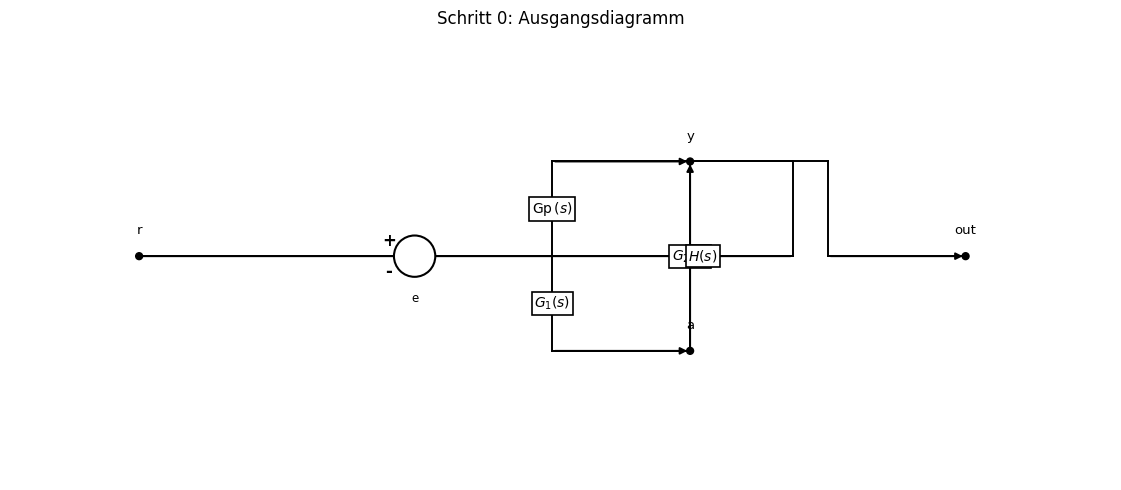

### Schritt 1

**Knoten `a` wird eliminiert** (Serienschaltung).

`a` hat 1 eingehende und 1 ausgehende Kante(n). Jede Kombination aus einer eingehenden Kante $u\to a$ (Verstärkung $a$) und einer ausgehenden Kante $a\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \to w$ mit Verstärkung $a \cdot b$:

- $e \to a \to y$ ergibt $(\frac{1}{s + 1}) \cdot (\frac{2}{s}) = \frac{2}{s \left(s + 1\right)}$, addiert zur bereits vorhandenen Kante $e \to y$ (alt: $\frac{1}{2}$) &rarr; neu: $\frac{s \left(s + 1\right) + 4}{2 s \left(s + 1\right)}$ (**Parallelschaltung**)

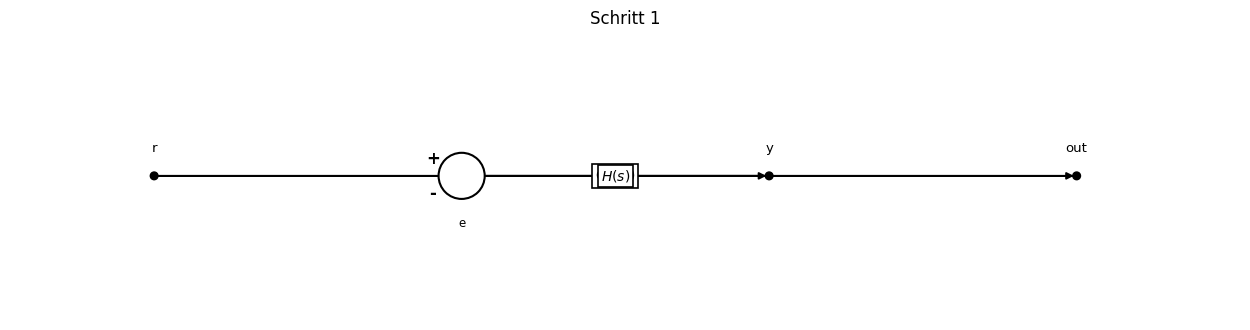

### Schritt 2

**Knoten `e` wird eliminiert** (Serien-/Verzweigungs-Zusammenfassung).

`e` hat 2 eingehende und 1 ausgehende Kante(n). Jede Kombination aus einer eingehenden Kante $u\to e$ (Verstärkung $a$) und einer ausgehenden Kante $e\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \to w$ mit Verstärkung $a \cdot b$:

- $r \to e \to y$: neue Kante $r \to y$ mit $(1) \cdot (\frac{s \left(s + 1\right) + 4}{2 s \left(s + 1\right)}) = \frac{s \left(s + 1\right) + 4}{2 s \left(s + 1\right)}$

- $y \to e \to y$: da Start- und Zielknoten hier gleich sind, entsteht eine **neue Rückführschleife** bei `y` mit $(- \frac{1}{10}) \cdot (\frac{s \left(s + 1\right) + 4}{2 s \left(s + 1\right)}) = \frac{- s \left(s + 1\right) - 4}{20 s \left(s + 1\right)}$

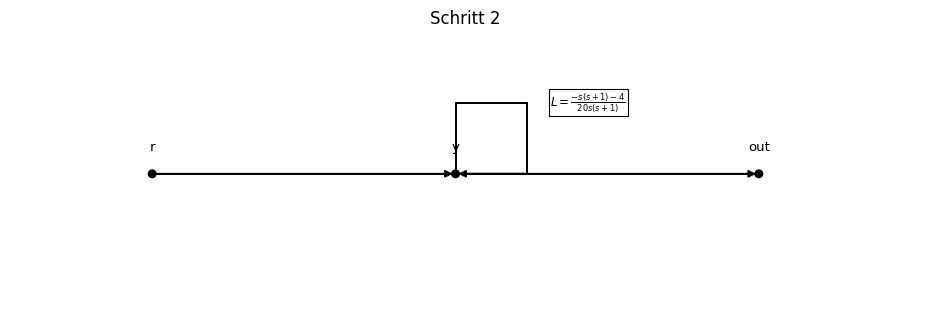

### Schritt 3

**Rückführschleife bei Knoten `y` wird aufgelöst.**

Es gibt eine Schleife $y \to y$ mit Schleifenverstärkung $L=\frac{- s \left(s + 1\right) - 4}{20 s \left(s + 1\right)}$.

Regel: alle *eingehenden* Kanten von `y` (außer der Schleife selbst) werden mit $\dfrac{1}{1-L} = \dfrac{1}{1-(\frac{- s \left(s + 1\right) - 4}{20 s \left(s + 1\right)})} = \frac{20 s \left(s + 1\right)}{21 s \left(s + 1\right) + 4}$ multipliziert, danach wird die Schleife entfernt:

- Kante $r \to y$: $\frac{s \left(s + 1\right) + 4}{2 s \left(s + 1\right)} \cdot \frac{20 s \left(s + 1\right)}{21 s \left(s + 1\right) + 4} = \frac{10 \left(s \left(s + 1\right) + 4\right)}{21 s \left(s + 1\right) + 4}$

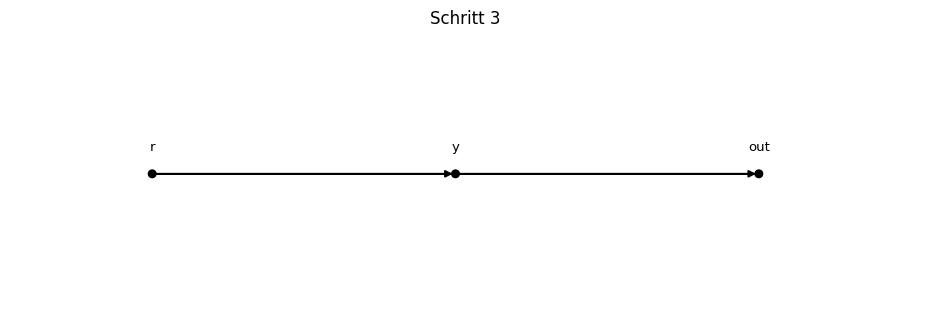

### Schritt 4

**Knoten `y` wird eliminiert** (Serienschaltung).

`y` hat 1 eingehende und 1 ausgehende Kante(n). Jede Kombination aus einer eingehenden Kante $u\to y$ (Verstärkung $a$) und einer ausgehenden Kante $y\to w$ (Verstärkung $b$) ergibt einen neuen direkten Pfad $u \to w$ mit Verstärkung $a \cdot b$:

- $r \to y \to out$: neue Kante $r \to out$ mit $(\frac{10 \left(s \left(s + 1\right) + 4\right)}{21 s \left(s + 1\right) + 4}) \cdot (1) = \frac{10 \left(s \left(s + 1\right) + 4\right)}{21 s \left(s + 1\right) + 4}$

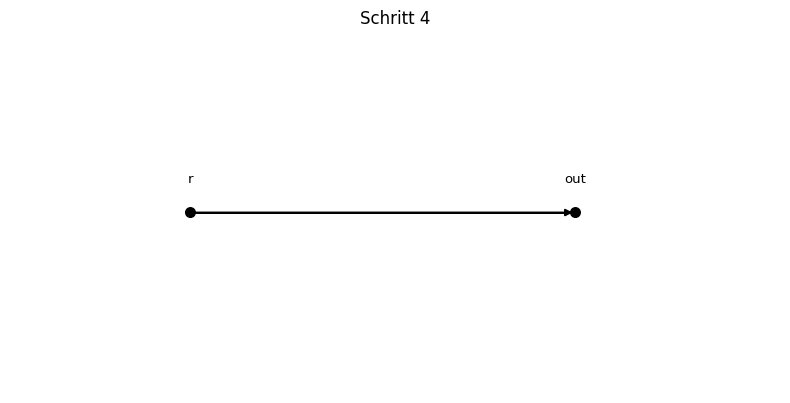

### Ergebnis

$$ \dfrac{out(s)}{r(s)} = \frac{10 \left(s \left(s + 1\right) + 4\right)}{21 s \left(s + 1\right) + 4} = \frac{10 s^{2} + 10 s + 40}{21 s^{2} + 21 s + 4} $$

In [46]:
example_specs = {
    'A_serie': r'''
r -> x1 : 1/(s+1) [G1]
x1 -> x2 : 2/(s+3) [G2]
x2 -> out : 4 [G3]
''',
    'B_parallel': r'''
r -> e : 1
e -> out : 1/(s+2) [G1]
e -> out : 3/(s+5) [G2]
''',
    'C_regelkreis': r'''
@sum e
r -> e : 1
e -> a : 1/(s+1) [G1]
a -> y : 2/s [G2]
e -> y : 1/2 [Gp]
y -> out : 1
y -> e : 1/10 [H] -
''',
    'D_kaskade': r'''
@sum e1
@sum e2
r -> e1 : 1
e1 -> e2 : 3/(s+2) [G1]
e2 -> y : 1/s [G2]
y -> e2 : 1/2 [H2] -
y -> out : 1
y -> e1 : 1/5 [H1] -
'''
}

example_name = 'C_regelkreis'   # A_serie | B_parallel | C_regelkreis | D_kaskade

G_ex = build_diagram_from_text(example_specs[example_name])
reduce_and_show(G_ex);